C:\Users\GARIKINA BALAJI\AppData\Local\Temp\ipykernel_12356\185389577.py:94: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = {k: pd.read_sql(v, conn) for k, v in queries.items()}
C:\Users\GARIKINA BALAJI\AppData\Local\Temp\ipykernel_12356\185389577.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df["district_area"], y="district", x="area", palette="crest")
C:\Users\GARIKINA BALAJI\AppData\Local\Temp\ipykernel_12356\185389577.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df["district_prod"], y="district", x="p

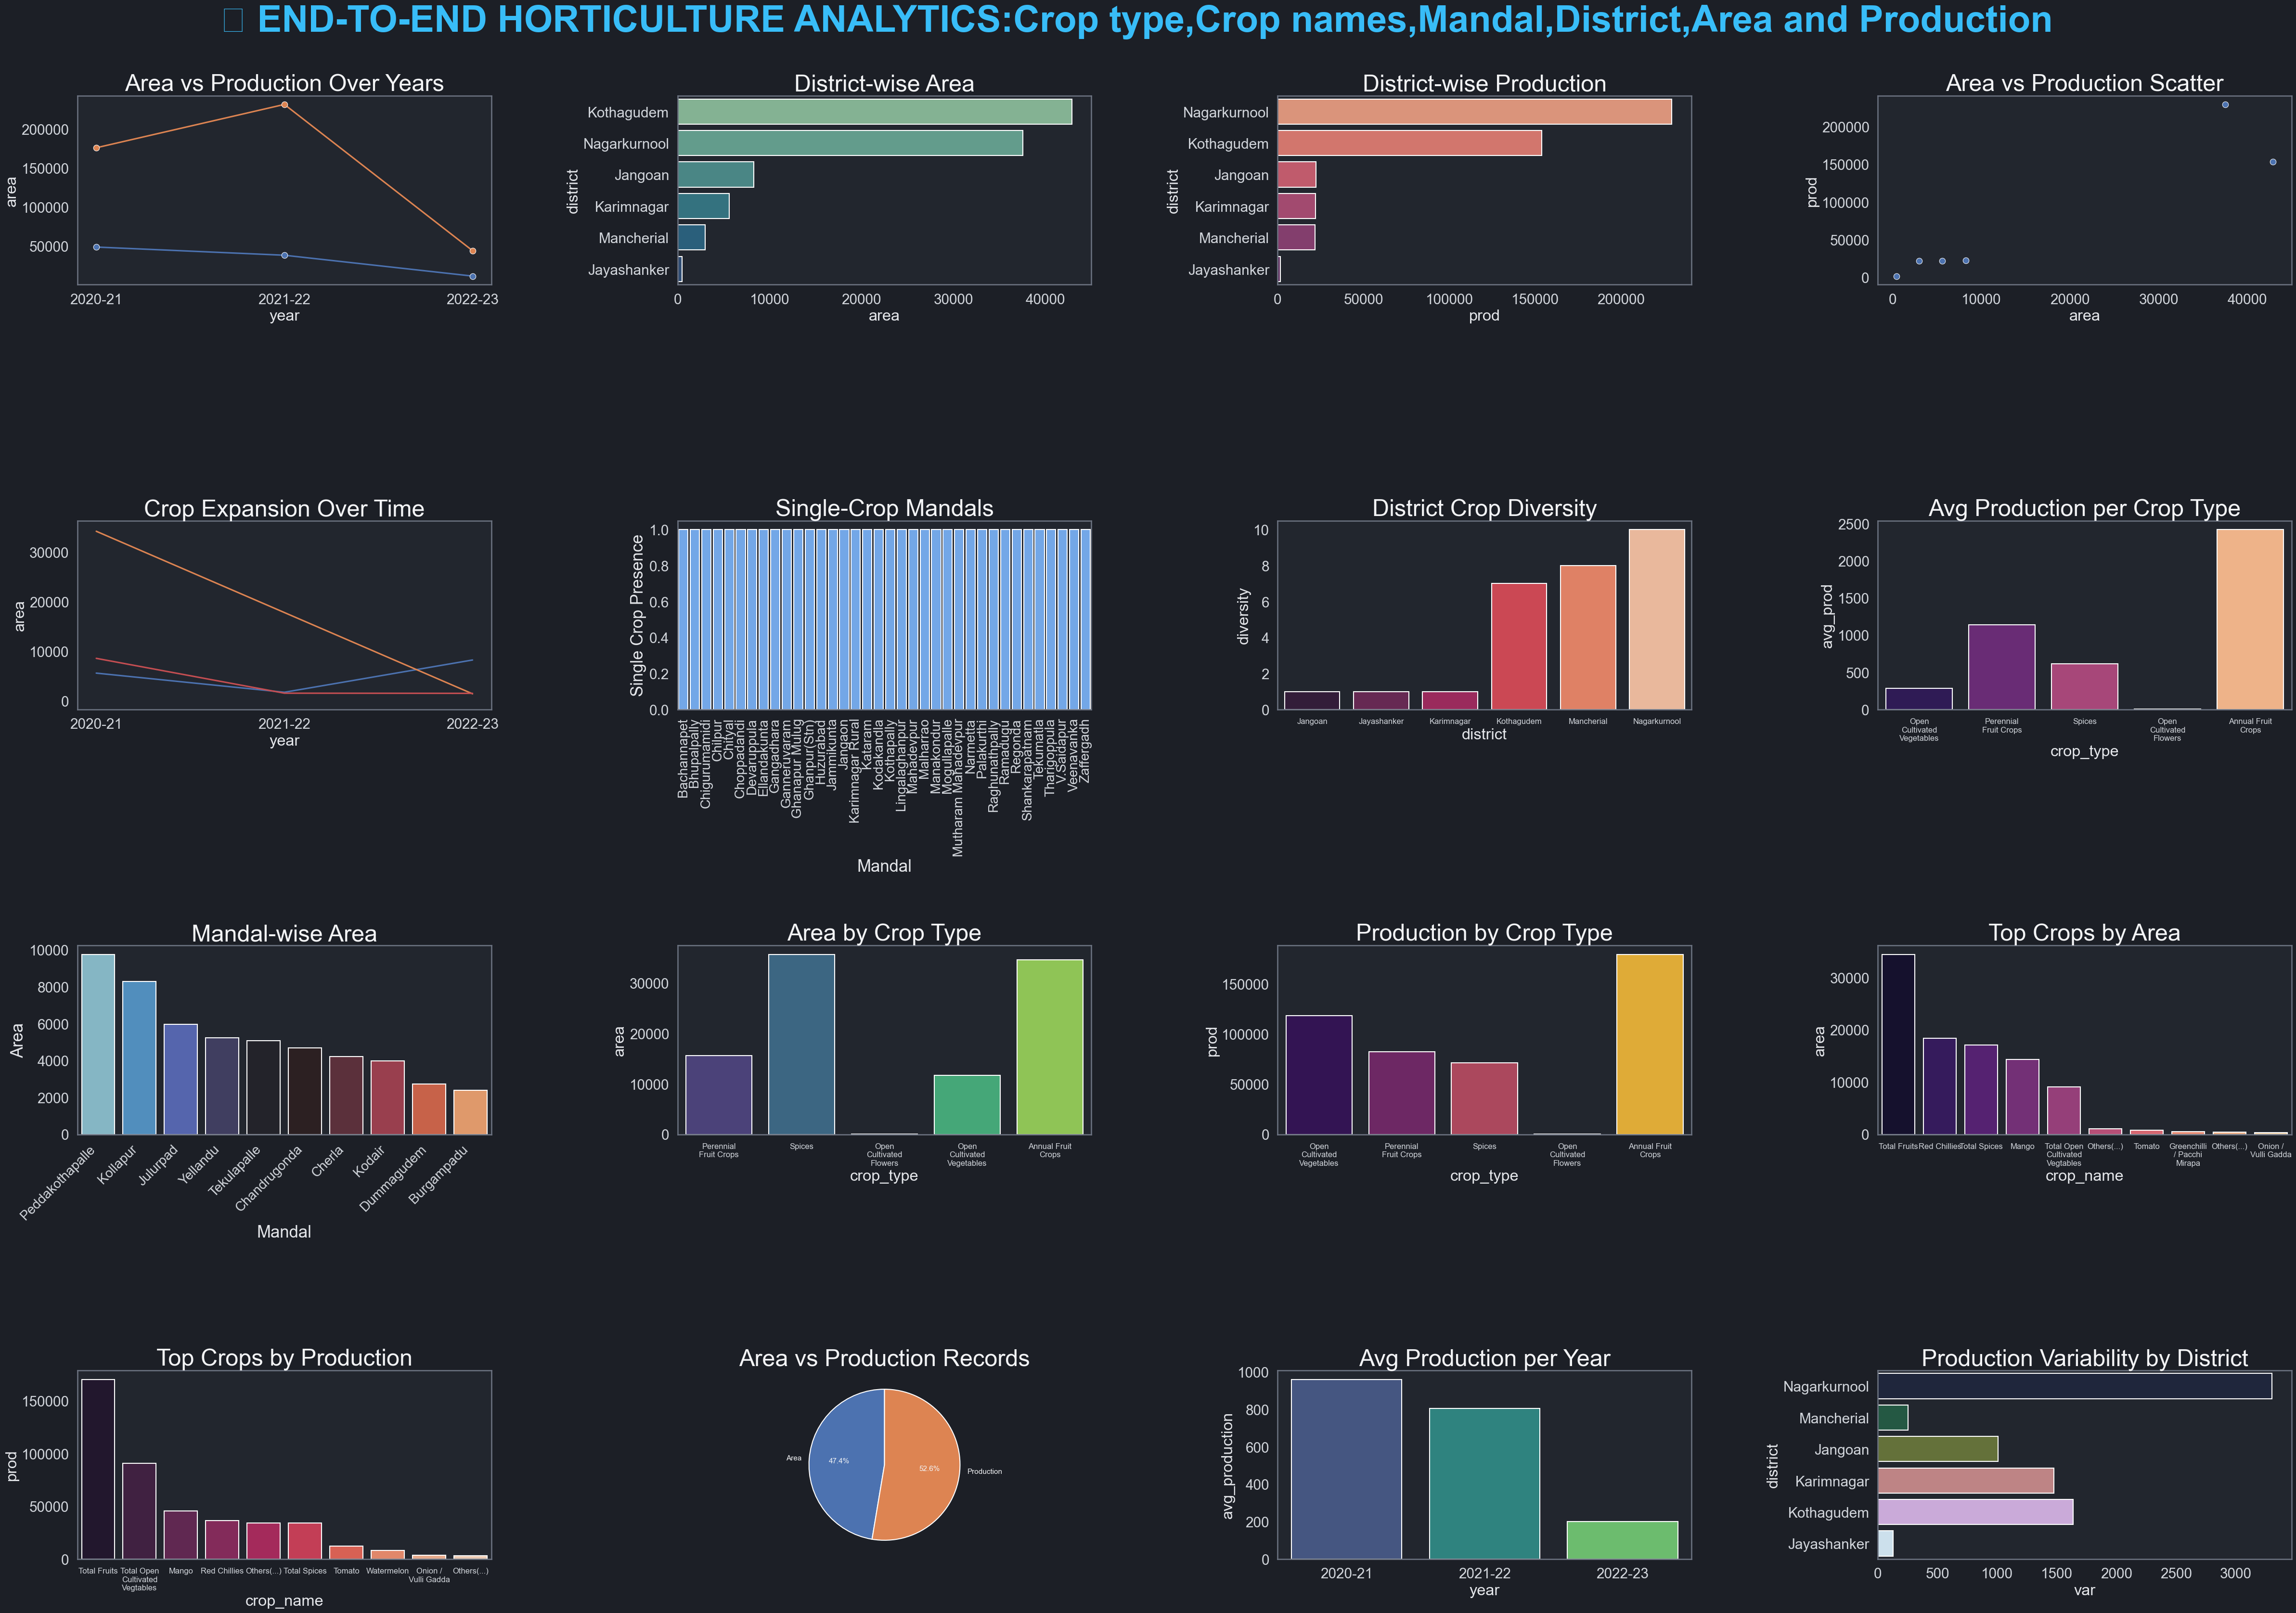

In [4]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# --------------------------------------------------
# CLEAN + WRAP FUNCTION (FOR MODERATE LABEL CHARTS)
# --------------------------------------------------
def clean_and_wrap_ticklabels(axis, width=12):
    labels = [label.get_text() for label in axis.get_xticklabels()]
    cleaned = []

    for label in labels:
        label = str(label)

        if "(" in label and len(label) > 20:
            main = label.split("(")[0].strip()
            label = f"{main}(...)"

        label = label.replace("/", " / ")

        wrapped = "\n".join(
            textwrap.wrap(label, width=width, break_long_words=False)
        )

        cleaned.append(wrapped)

    axis.set_xticklabels(cleaned, fontsize=12)


# --------------------------------------------------
# FONT SETTINGS
# --------------------------------------------------
DASHBOARD_TITLE_SIZE = 55
CHART_TITLE_SIZE = 35
AXIS_LABEL_SIZE = 25
TICK_LABEL_SIZE = 20


# --------------------------------------------------
# DARK THEME (UNCHANGED COLORS)
# --------------------------------------------------
sns.set_theme(
    style="dark",
    context="talk",
    font_scale=1.3,
    rc={
        "figure.facecolor": "#1C1F26",
        "axes.facecolor": "#22262E",
        "axes.edgecolor": "#6B7280",
        "axes.labelcolor": "#E5E7EB",
        "text.color": "#F3F4F6",
        "xtick.color": "#D1D5DB",
        "ytick.color": "#D1D5DB",
        "grid.color": "#374151",
        "grid.alpha": 0.35,
        "legend.facecolor": "#1C1F26",
        "legend.edgecolor": "#4B5563"
    }
)

# --------------------------------------------------
# DATABASE CONNECTION
# --------------------------------------------------
db_config = {
    "host": "localhost",
    "user": "root",
    "password": "2855@Mysql",
    "database": "agriculture"
}

conn = mysql.connector.connect(**db_config)

queries = {
    "area_prod_year": "SELECT y.year, SUM(CASE WHEN ap.area_production='area' THEN ap.value ELSE 0 END) area, SUM(CASE WHEN ap.area_production='production' THEN ap.value ELSE 0 END) prod FROM area_production ap JOIN year y ON ap.year_id=y.year_id GROUP BY y.year ORDER BY y.year;",
    "district_area": "SELECT d.district, SUM(ap.value) area FROM area_production ap JOIN district d ON ap.district_id=d.district_id WHERE ap.area_production='area' GROUP BY d.district ORDER BY area DESC;",
    "district_prod": "SELECT d.district, SUM(ap.value) prod FROM area_production ap JOIN district d ON ap.district_id=d.district_id WHERE ap.area_production='production' GROUP BY d.district ORDER BY prod DESC;",
    "district_scatter": "SELECT d.district, SUM(CASE WHEN ap.area_production='area' THEN ap.value ELSE 0 END) area, SUM(CASE WHEN ap.area_production='production' THEN ap.value ELSE 0 END) prod FROM area_production ap JOIN district d ON ap.district_id=d.district_id GROUP BY d.district;",
    "mandal_area": "SELECT m.mandal, SUM(ap.value) area FROM area_production ap JOIN mandal m ON ap.mandal_id=m.mandal_id WHERE ap.area_production='area' GROUP BY m.mandal ORDER BY area DESC LIMIT 10;",
    "crop_area": "SELECT c.crop_type, SUM(ap.value) area FROM area_production ap JOIN crop c ON ap.crop_id=c.crop_id WHERE ap.area_production='area' GROUP BY c.crop_type;",
    "crop_prod": "SELECT c.crop_type, SUM(ap.value) prod FROM area_production ap JOIN crop c ON ap.crop_id=c.crop_id WHERE ap.area_production='production' GROUP BY c.crop_type;",
    "top_crop_area": "SELECT c.crop_name, SUM(ap.value) area FROM area_production ap JOIN crop c ON ap.crop_id=c.crop_id WHERE ap.area_production='area' GROUP BY c.crop_name ORDER BY area DESC LIMIT 10;",
    "top_crop_prod": "SELECT c.crop_name, SUM(ap.value) prod FROM area_production ap JOIN crop c ON ap.crop_id=c.crop_id WHERE ap.area_production='production' GROUP BY c.crop_name ORDER BY prod DESC LIMIT 10;",
    "record_prop": "SELECT area_production, COUNT(*) cnt FROM area_production GROUP BY area_production;",
    "crop_expand": "SELECT y.year, c.crop_type, SUM(ap.value) area FROM area_production ap JOIN crop c ON ap.crop_id=c.crop_id JOIN year y ON ap.year_id=y.year_id WHERE ap.area_production='area' GROUP BY y.year, c.crop_type;",
    "single_mandal": "SELECT m.mandal, COUNT(DISTINCT c.crop_name) crops FROM area_production ap JOIN mandal m ON ap.mandal_id=m.mandal_id JOIN crop c ON ap.crop_id=c.crop_id GROUP BY m.mandal HAVING crops=1;",
    "diversity": "SELECT d.district, COUNT(DISTINCT c.crop_name) diversity FROM area_production ap JOIN district d ON ap.district_id=d.district_id JOIN crop c ON ap.crop_id=c.crop_id GROUP BY d.district;",
    "avg_prod": "SELECT c.crop_type, ROUND(AVG(ap.value),2) avg_prod FROM area_production ap JOIN crop c ON ap.crop_id=c.crop_id WHERE ap.area_production='production' GROUP BY c.crop_type;",
    "avg_prod_year": "SELECT y.year, ROUND(AVG(ap.value),2) avg_production FROM area_production ap JOIN year y ON ap.year_id=y.year_id WHERE ap.area_production='production' GROUP BY y.year ORDER BY y.year;",
    "variability": "SELECT d.district, STDDEV_POP(ap.value) var FROM area_production ap JOIN district d ON ap.district_id=d.district_id WHERE ap.area_production='production' GROUP BY d.district;"
}

df = {k: pd.read_sql(v, conn) for k, v in queries.items()}
conn.close()

# --------------------------------------------------
# DASHBOARD
# --------------------------------------------------
plt.figure(figsize=(50, 38))

plt.suptitle(
    "🌱 END-TO-END HORTICULTURE ANALYTICS:Crop type,Crop names,Mandal,District,Area and Production",
    fontsize=DASHBOARD_TITLE_SIZE,
    fontweight="bold",
    color="#38BDF8",
    y=0.97
)

# ROW 1
plt.subplot(4,4,1)
sns.lineplot(data=df["area_prod_year"], x="year", y="area", marker="o")
sns.lineplot(data=df["area_prod_year"], x="year", y="prod", marker="o")
plt.title("Area vs Production Over Years", fontsize=CHART_TITLE_SIZE)

plt.subplot(4,4,2)
sns.barplot(data=df["district_area"], y="district", x="area", palette="crest")
plt.title("District-wise Area", fontsize=CHART_TITLE_SIZE)

plt.subplot(4,4,3)
sns.barplot(data=df["district_prod"], y="district", x="prod", palette="flare")
plt.title("District-wise Production", fontsize=CHART_TITLE_SIZE)

plt.subplot(4,4,4)
sns.scatterplot(data=df["district_scatter"], x="area", y="prod")
plt.title("Area vs Production Scatter", fontsize=CHART_TITLE_SIZE)

# ROW 2
plt.subplot(4,4,5)
sns.lineplot(data=df["crop_expand"], x="year", y="area", hue="crop_type", legend=False)
plt.title("Crop Expansion Over Time", fontsize=CHART_TITLE_SIZE)

plt.subplot(4,4,6)
sns.barplot(data=df["single_mandal"], x="mandal", y="crops", color="#60A5FA")
plt.title("Single-Crop Mandals", fontsize=CHART_TITLE_SIZE)
plt.xticks(rotation=90, fontsize=TICK_LABEL_SIZE)
plt.xlabel("Mandal", fontsize=AXIS_LABEL_SIZE)
plt.ylabel("Single Crop Presence", fontsize=AXIS_LABEL_SIZE)

plt.subplot(4,4,7)
sns.barplot(data=df["diversity"], x="district", y="diversity", palette="rocket")
plt.title("District Crop Diversity", fontsize=CHART_TITLE_SIZE)
clean_and_wrap_ticklabels(plt.gca())

plt.subplot(4,4,8)
sns.barplot(data=df["avg_prod"], x="crop_type", y="avg_prod", palette="magma")
plt.title("Avg Production per Crop Type", fontsize=CHART_TITLE_SIZE)
clean_and_wrap_ticklabels(plt.gca())

# ROW 3
plt.subplot(4,4,9)
sns.barplot(data=df["mandal_area"], x="mandal", y="area", palette="icefire")
plt.title("Mandal-wise Area", fontsize=CHART_TITLE_SIZE)
plt.xticks(rotation=45, ha="right", fontsize=TICK_LABEL_SIZE)  # FIXED
plt.xlabel("Mandal", fontsize=AXIS_LABEL_SIZE)
plt.ylabel("Area", fontsize=AXIS_LABEL_SIZE)

plt.subplot(4,4,10)
sns.barplot(data=df["crop_area"], x="crop_type", y="area", palette="viridis")
plt.title("Area by Crop Type", fontsize=CHART_TITLE_SIZE)
clean_and_wrap_ticklabels(plt.gca())

plt.subplot(4,4,11)
sns.barplot(data=df["crop_prod"], x="crop_type", y="prod", palette="inferno")
plt.title("Production by Crop Type", fontsize=CHART_TITLE_SIZE)
clean_and_wrap_ticklabels(plt.gca())

plt.subplot(4,4,12)
sns.barplot(data=df["top_crop_area"], x="crop_name", y="area", palette="magma")
plt.title("Top Crops by Area", fontsize=CHART_TITLE_SIZE)
clean_and_wrap_ticklabels(plt.gca())

# ROW 4
plt.subplot(4,4,13)
sns.barplot(data=df["top_crop_prod"], x="crop_name", y="prod", palette="rocket")
plt.title("Top Crops by Production", fontsize=CHART_TITLE_SIZE)
clean_and_wrap_ticklabels(plt.gca())

plt.subplot(4,4,14)
plt.pie(df["record_prop"]["cnt"],
        labels=df["record_prop"]["area_production"],
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize":11})
plt.title("Area vs Production Records", fontsize=CHART_TITLE_SIZE)

plt.subplot(4,4,15)
sns.barplot(data=df["avg_prod_year"], x="year", y="avg_production", palette="viridis")
plt.title("Avg Production per Year", fontsize=CHART_TITLE_SIZE)

plt.subplot(4,4,16)
sns.barplot(data=df["variability"], y="district", x="var", palette="cubehelix")
plt.title("Production Variability by District", fontsize=CHART_TITLE_SIZE)

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    top=0.92,
    bottom=0.12,
    hspace=1.25,
    wspace=0.45
)

plt.show()


C:\Users\GARIKINA BALAJI\AppData\Local\Temp\ipykernel_12356\1527396730.py:94: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = {k: pd.read_sql(v, conn) for k, v in queries.items()}
C:\Users\GARIKINA BALAJI\AppData\Local\Temp\ipykernel_12356\1527396730.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df["district_area"], y="district", x="area", palette="crest")
C:\Users\GARIKINA BALAJI\AppData\Local\Temp\ipykernel_12356\1527396730.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df["district_prod"], y="district", x

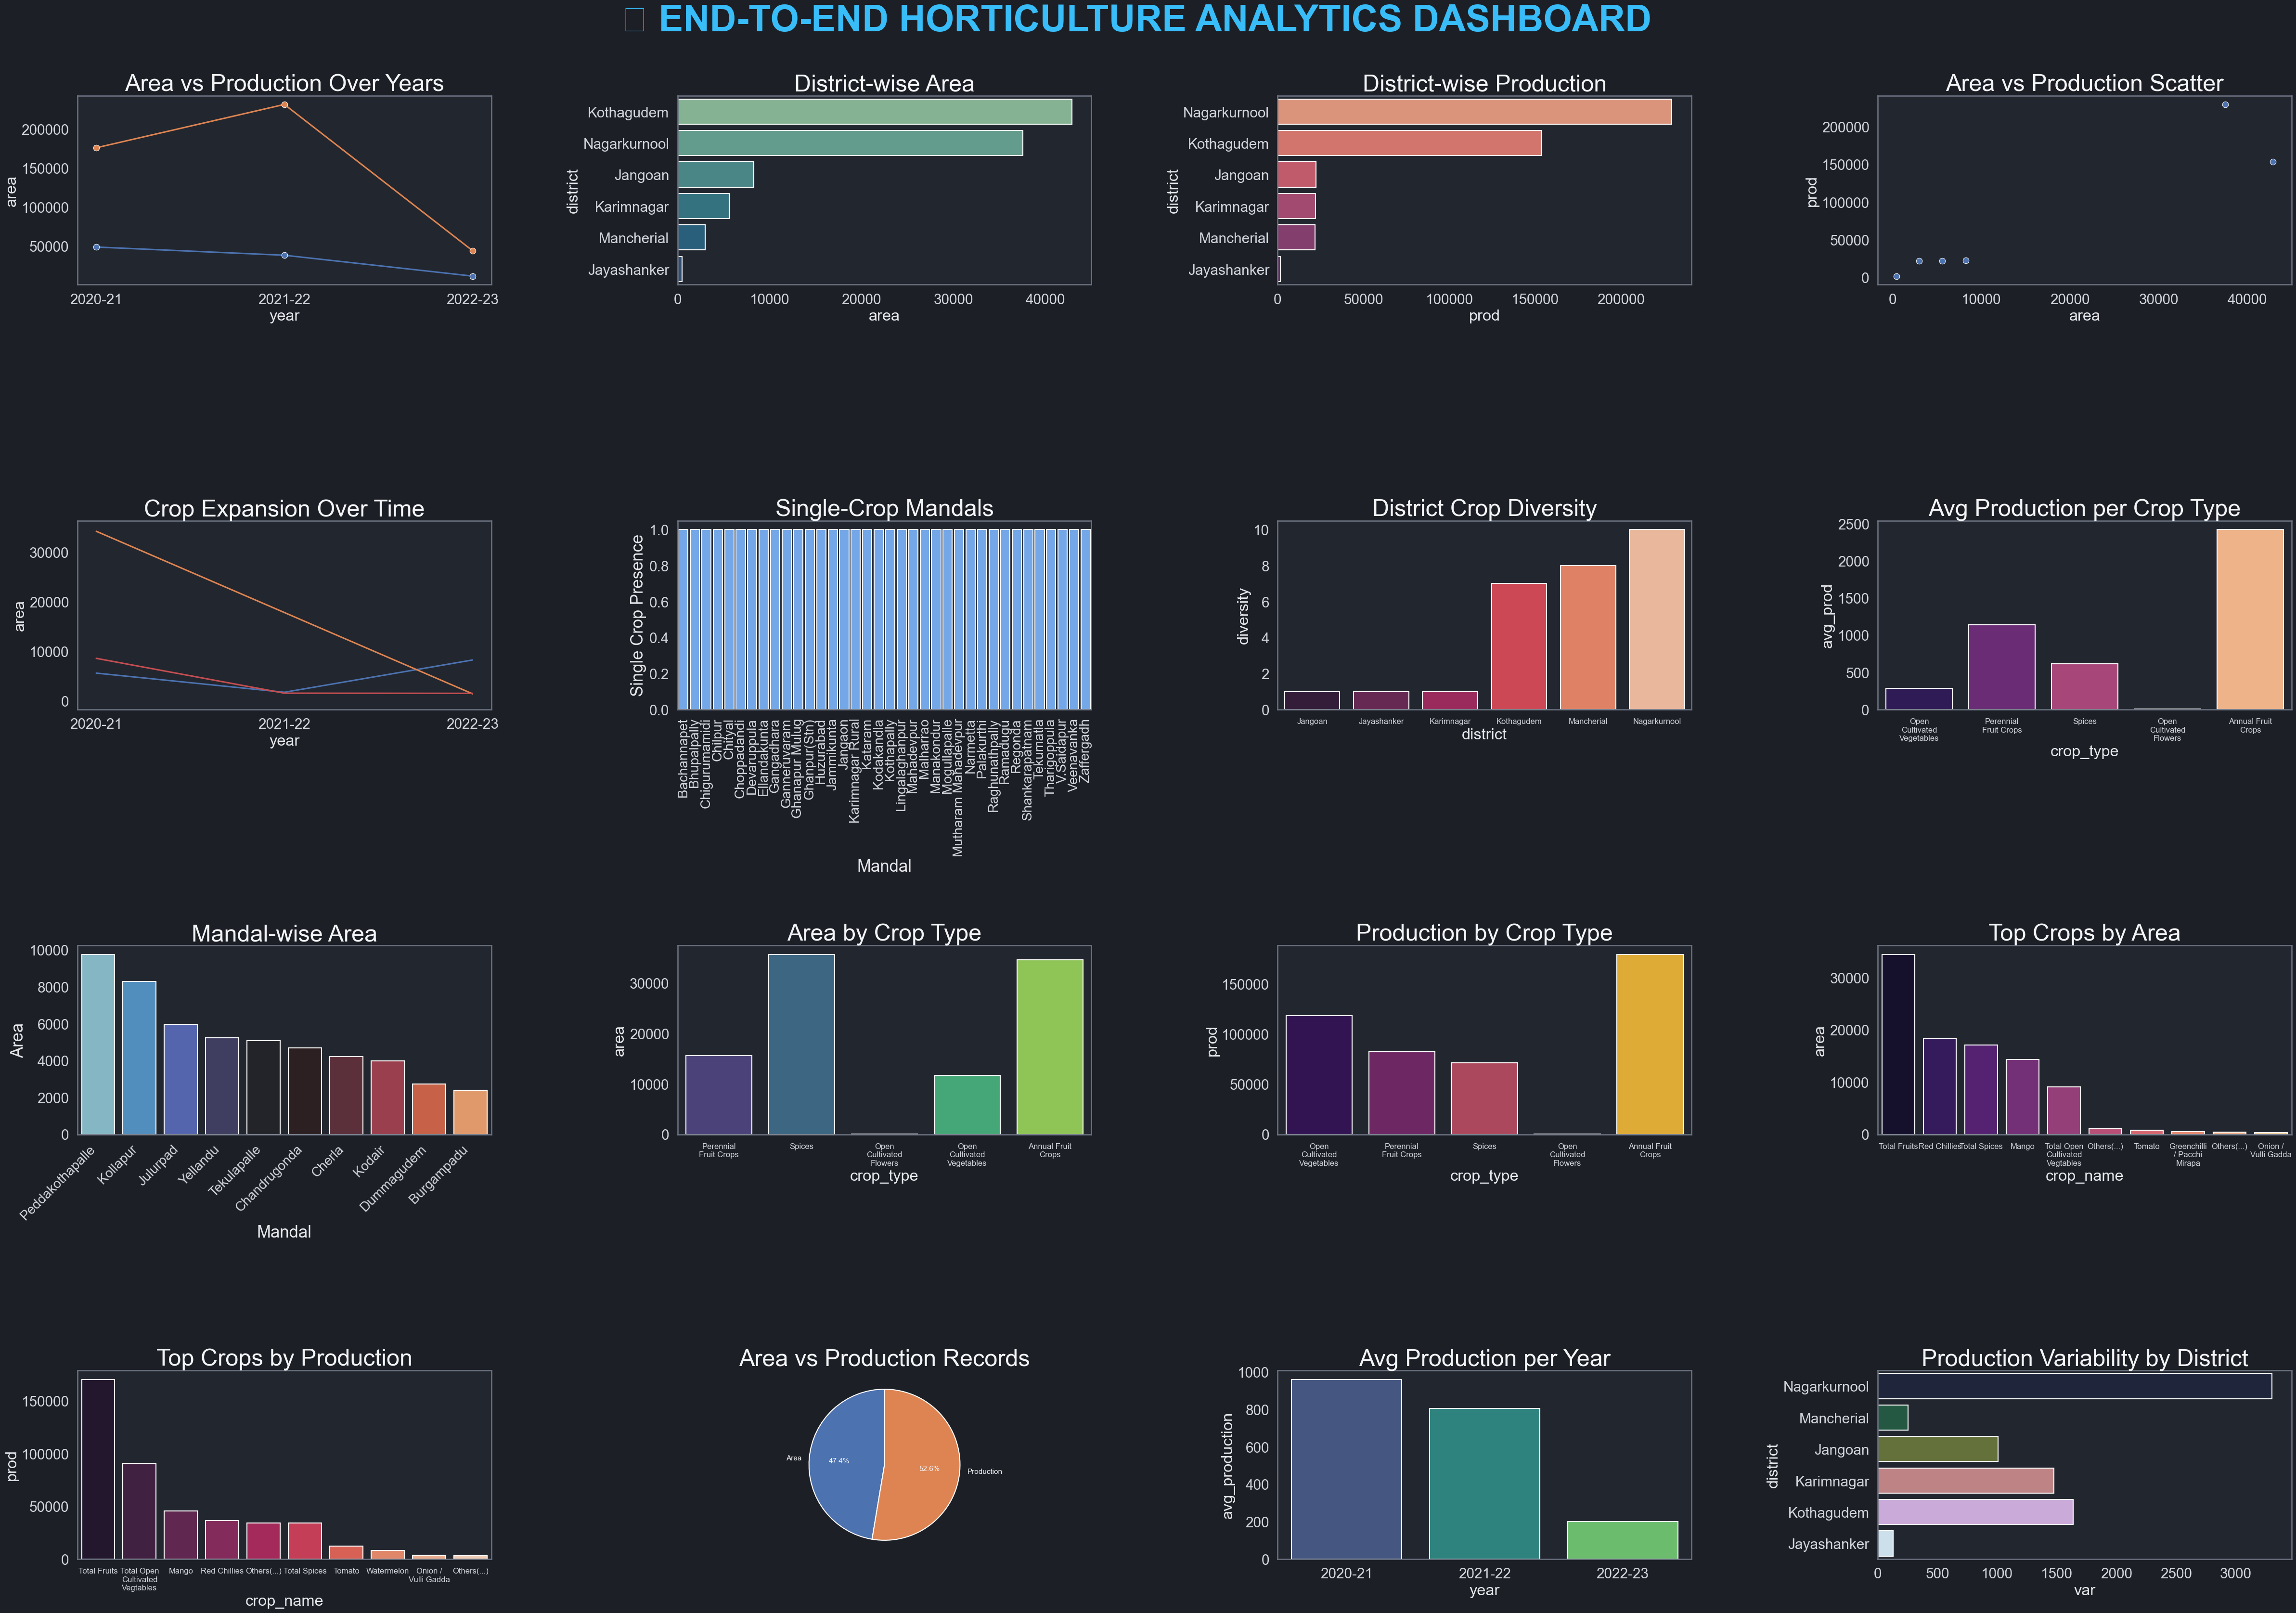

In [2]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap

# --------------------------------------------------
# CLEAN + WRAP FUNCTION (FOR MODERATE LABEL CHARTS)
# --------------------------------------------------
def clean_and_wrap_ticklabels(axis, width=12):
    labels = [label.get_text() for label in axis.get_xticklabels()]
    cleaned = []

    for label in labels:
        label = str(label)

        if "(" in label and len(label) > 20:
            main = label.split("(")[0].strip()
            label = f"{main}(...)"

        label = label.replace("/", " / ")

        wrapped = "\n".join(
            textwrap.wrap(label, width=width, break_long_words=False)
        )

        cleaned.append(wrapped)

    axis.set_xticklabels(cleaned, fontsize=12)


# --------------------------------------------------
# FONT SETTINGS
# --------------------------------------------------
DASHBOARD_TITLE_SIZE = 55
CHART_TITLE_SIZE = 35
AXIS_LABEL_SIZE = 25
TICK_LABEL_SIZE = 20


# --------------------------------------------------
# DARK THEME (UNCHANGED COLORS)
# --------------------------------------------------
sns.set_theme(
    style="dark",
    context="talk",
    font_scale=1.3,
    rc={
        "figure.facecolor": "#1C1F26",
        "axes.facecolor": "#22262E",
        "axes.edgecolor": "#6B7280",
        "axes.labelcolor": "#E5E7EB",
        "text.color": "#F3F4F6",
        "xtick.color": "#D1D5DB",
        "ytick.color": "#D1D5DB",
        "grid.color": "#374151",
        "grid.alpha": 0.35,
        "legend.facecolor": "#1C1F26",
        "legend.edgecolor": "#4B5563"
    }
)

# --------------------------------------------------
# DATABASE CONNECTION
# --------------------------------------------------
db_config = {
    "host": "localhost",
    "user": "root",
    "password": "2855@Mysql",
    "database": "agriculture"
}

conn = mysql.connector.connect(**db_config)

queries = {
    "area_prod_year": "SELECT y.year, SUM(CASE WHEN ap.area_production='area' THEN ap.value ELSE 0 END) area, SUM(CASE WHEN ap.area_production='production' THEN ap.value ELSE 0 END) prod FROM area_production ap JOIN year y ON ap.year_id=y.year_id GROUP BY y.year ORDER BY y.year;",
    "district_area": "SELECT d.district, SUM(ap.value) area FROM area_production ap JOIN district d ON ap.district_id=d.district_id WHERE ap.area_production='area' GROUP BY d.district ORDER BY area DESC;",
    "district_prod": "SELECT d.district, SUM(ap.value) prod FROM area_production ap JOIN district d ON ap.district_id=d.district_id WHERE ap.area_production='production' GROUP BY d.district ORDER BY prod DESC;",
    "district_scatter": "SELECT d.district, SUM(CASE WHEN ap.area_production='area' THEN ap.value ELSE 0 END) area, SUM(CASE WHEN ap.area_production='production' THEN ap.value ELSE 0 END) prod FROM area_production ap JOIN district d ON ap.district_id=d.district_id GROUP BY d.district;",
    "mandal_area": "SELECT m.mandal, SUM(ap.value) area FROM area_production ap JOIN mandal m ON ap.mandal_id=m.mandal_id WHERE ap.area_production='area' GROUP BY m.mandal ORDER BY area DESC LIMIT 10;",
    "crop_area": "SELECT c.crop_type, SUM(ap.value) area FROM area_production ap JOIN crop c ON ap.crop_id=c.crop_id WHERE ap.area_production='area' GROUP BY c.crop_type;",
    "crop_prod": "SELECT c.crop_type, SUM(ap.value) prod FROM area_production ap JOIN crop c ON ap.crop_id=c.crop_id WHERE ap.area_production='production' GROUP BY c.crop_type;",
    "top_crop_area": "SELECT c.crop_name, SUM(ap.value) area FROM area_production ap JOIN crop c ON ap.crop_id=c.crop_id WHERE ap.area_production='area' GROUP BY c.crop_name ORDER BY area DESC LIMIT 10;",
    "top_crop_prod": "SELECT c.crop_name, SUM(ap.value) prod FROM area_production ap JOIN crop c ON ap.crop_id=c.crop_id WHERE ap.area_production='production' GROUP BY c.crop_name ORDER BY prod DESC LIMIT 10;",
    "record_prop": "SELECT area_production, COUNT(*) cnt FROM area_production GROUP BY area_production;",
    "crop_expand": "SELECT y.year, c.crop_type, SUM(ap.value) area FROM area_production ap JOIN crop c ON ap.crop_id=c.crop_id JOIN year y ON ap.year_id=y.year_id WHERE ap.area_production='area' GROUP BY y.year, c.crop_type;",
    "single_mandal": "SELECT m.mandal, COUNT(DISTINCT c.crop_name) crops FROM area_production ap JOIN mandal m ON ap.mandal_id=m.mandal_id JOIN crop c ON ap.crop_id=c.crop_id GROUP BY m.mandal HAVING crops=1;",
    "diversity": "SELECT d.district, COUNT(DISTINCT c.crop_name) diversity FROM area_production ap JOIN district d ON ap.district_id=d.district_id JOIN crop c ON ap.crop_id=c.crop_id GROUP BY d.district;",
    "avg_prod": "SELECT c.crop_type, ROUND(AVG(ap.value),2) avg_prod FROM area_production ap JOIN crop c ON ap.crop_id=c.crop_id WHERE ap.area_production='production' GROUP BY c.crop_type;",
    "avg_prod_year": "SELECT y.year, ROUND(AVG(ap.value),2) avg_production FROM area_production ap JOIN year y ON ap.year_id=y.year_id WHERE ap.area_production='production' GROUP BY y.year ORDER BY y.year;",
    "variability": "SELECT d.district, STDDEV_POP(ap.value) var FROM area_production ap JOIN district d ON ap.district_id=d.district_id WHERE ap.area_production='production' GROUP BY d.district;"
}

df = {k: pd.read_sql(v, conn) for k, v in queries.items()}
conn.close()

# --------------------------------------------------
# DASHBOARD
# --------------------------------------------------
plt.figure(figsize=(50, 38))

plt.suptitle(
    "🌱 END-TO-END HORTICULTURE ANALYTICS DASHBOARD",
    fontsize=DASHBOARD_TITLE_SIZE,
    fontweight="bold",
    color="#38BDF8",
    y=0.97
)

# ROW 1
plt.subplot(4,4,1)
sns.lineplot(data=df["area_prod_year"], x="year", y="area", marker="o")
sns.lineplot(data=df["area_prod_year"], x="year", y="prod", marker="o")
plt.title("Area vs Production Over Years", fontsize=CHART_TITLE_SIZE)

plt.subplot(4,4,2)
sns.barplot(data=df["district_area"], y="district", x="area", palette="crest")
plt.title("District-wise Area", fontsize=CHART_TITLE_SIZE)

plt.subplot(4,4,3)
sns.barplot(data=df["district_prod"], y="district", x="prod", palette="flare")
plt.title("District-wise Production", fontsize=CHART_TITLE_SIZE)

plt.subplot(4,4,4)
sns.scatterplot(data=df["district_scatter"], x="area", y="prod")
plt.title("Area vs Production Scatter", fontsize=CHART_TITLE_SIZE)

# ROW 2
plt.subplot(4,4,5)
sns.lineplot(data=df["crop_expand"], x="year", y="area", hue="crop_type", legend=False)
plt.title("Crop Expansion Over Time", fontsize=CHART_TITLE_SIZE)

plt.subplot(4,4,6)
sns.barplot(data=df["single_mandal"], x="mandal", y="crops", color="#60A5FA")
plt.title("Single-Crop Mandals", fontsize=CHART_TITLE_SIZE)
plt.xticks(rotation=90, fontsize=TICK_LABEL_SIZE)
plt.xlabel("Mandal", fontsize=AXIS_LABEL_SIZE)
plt.ylabel("Single Crop Presence", fontsize=AXIS_LABEL_SIZE)

plt.subplot(4,4,7)
sns.barplot(data=df["diversity"], x="district", y="diversity", palette="rocket")
plt.title("District Crop Diversity", fontsize=CHART_TITLE_SIZE)
clean_and_wrap_ticklabels(plt.gca())

plt.subplot(4,4,8)
sns.barplot(data=df["avg_prod"], x="crop_type", y="avg_prod", palette="magma")
plt.title("Avg Production per Crop Type", fontsize=CHART_TITLE_SIZE)
clean_and_wrap_ticklabels(plt.gca())

# ROW 3
plt.subplot(4,4,9)
sns.barplot(data=df["mandal_area"], x="mandal", y="area", palette="icefire")
plt.title("Mandal-wise Area", fontsize=CHART_TITLE_SIZE)
plt.xticks(rotation=45, ha="right", fontsize=TICK_LABEL_SIZE)  # FIXED
plt.xlabel("Mandal", fontsize=AXIS_LABEL_SIZE)
plt.ylabel("Area", fontsize=AXIS_LABEL_SIZE)

plt.subplot(4,4,10)
sns.barplot(data=df["crop_area"], x="crop_type", y="area", palette="viridis")
plt.title("Area by Crop Type", fontsize=CHART_TITLE_SIZE)
clean_and_wrap_ticklabels(plt.gca())

plt.subplot(4,4,11)
sns.barplot(data=df["crop_prod"], x="crop_type", y="prod", palette="inferno")
plt.title("Production by Crop Type", fontsize=CHART_TITLE_SIZE)
clean_and_wrap_ticklabels(plt.gca())

plt.subplot(4,4,12)
sns.barplot(data=df["top_crop_area"], x="crop_name", y="area", palette="magma")
plt.title("Top Crops by Area", fontsize=CHART_TITLE_SIZE)
clean_and_wrap_ticklabels(plt.gca())

# ROW 4
plt.subplot(4,4,13)
sns.barplot(data=df["top_crop_prod"], x="crop_name", y="prod", palette="rocket")
plt.title("Top Crops by Production", fontsize=CHART_TITLE_SIZE)
clean_and_wrap_ticklabels(plt.gca())

plt.subplot(4,4,14)
plt.pie(df["record_prop"]["cnt"],
        labels=df["record_prop"]["area_production"],
        autopct="%1.1f%%",
        startangle=90,
        textprops={"fontsize":11})
plt.title("Area vs Production Records", fontsize=CHART_TITLE_SIZE)

plt.subplot(4,4,15)
sns.barplot(data=df["avg_prod_year"], x="year", y="avg_production", palette="viridis")
plt.title("Avg Production per Year", fontsize=CHART_TITLE_SIZE)

plt.subplot(4,4,16)
sns.barplot(data=df["variability"], y="district", x="var", palette="cubehelix")
plt.title("Production Variability by District", fontsize=CHART_TITLE_SIZE)

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    top=0.92,
    bottom=0.12,
    hspace=1.25,
    wspace=0.45
)

plt.show()
